# Equilibrium Sampling Evaluation on Fast-Folding Proteins

This notebook evaluates PLaTITO-19M on the equilibrium sampling benchmark for fast-folding proteins.

For each protein we:
1. Project both the MD reference trajectory and the PLaTITO-generated trajectory into the four slowest TICA components.
2. Visualize the resulting free energy surfaces side by side.
3. Compute MAE, RMSE, and Coverage metrics following the [BioEmu](https://github.com/microsoft/bioemu-benchmarks) protocol.

---
**Prerequisites**

**MD data:** MD trajectories of the fast-folding proteins ([Lindorff-Larsen et al., Science 2011](https://www.science.org/doi/10.1126/science.1208351)) are proprietary and cannot be redistributed. Please contact the authors to request access for research purposes.

**TICA models:** Once you have the MD data, use the [`notebooks/estimate_tica.ipynb`](estimate_tica.ipynb) notebook to fit a TICA model for each protein and save the resulting `.pkl` files under `data_dir/reference_TICA/`.

**PLaTITO results:** Generate trajectories for each protein using the instructions in the [Generate Trajectories](https://github.com/PanosAntoniadis/platito#generate-trajectories) section of the README. Starting structures are provided in `data/fast_folders/initial_structures/`. Results should be saved in one folder per protein (e.g. `results/bba/generated_coords.pt`).

## Configuration

First, we set the paths to the MD dataset and PLaTITO results below.

In [13]:
from pathlib import Path

data_dir = Path("/path/to/fast_folders/")        # MD dataset directory
results_dir = Path("/path/to/platito/results/platito_19M/")  # directory containing per-protein results

In [2]:
import json
import h5py
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from platito.utils.tica_utils import distances
from platito.utils.bioemu_utils import plot_free_energy_on_axes, DistributionMetrics2D

In [3]:
tica_dir = data_dir / "reference_TICA"

protein_names = ["bba", "villin", "trp_cage", "bbl", "a3d", "wwdomain", "ntl9", "protein_g", "protein_b", "homeodomain", "lambda"]

# Load data

In [4]:
tica_models = {}
xedges = {}
yedges = {}

for protein in protein_names:
    with open(tica_dir / f"{protein}.pkl", "rb") as f:
        tica_results = pickle.load(f)
        tica_models[protein] = tica_results["tica"]
        xedges[protein] = tica_results["tica_xedges"]
        yedges[protein] = tica_results["tica_yedges"]

In [5]:
with open(data_dir / "temperatures.json") as f:
    temperatures = json.load(f)

In [6]:
md_tica_features = {}
batch_size = 500000  # frames per batch — reduce if you run out of memory

for protein in protein_names:
    print(f"Loading {protein}")
    h5_file_path = data_dir / 'trajectories' / f"{protein}.h5"

    with h5py.File(h5_file_path, "r") as f:
        md_coords = np.array(f["ca_xyz_0000"])

    outputs = [
        distances(md_coords[start : start + batch_size])
        for start in range(0, len(md_coords), batch_size)
    ]

    md_ca_distances = np.concatenate(outputs, axis=0)
    md_tica_features[protein] = tica_models[protein].transform(md_ca_distances)[:, :2]

Loading bba
Loading villin
Loading trp_cage
Loading bbl
Loading a3d
Loading wwdomain
Loading ntl9
Loading protein_g
Loading protein_b
Loading homeodomain
Loading lambda


In [26]:
platito_tica_features = {}

for protein in protein_names:
    # We take the last 10 steps of each trajectory as equilibrium samples.
    gen_coords = torch.load(
        results_dir / protein / "generated_coords.pt", map_location="cpu"
    )[:, -10:, :, :]  # [number_of_trajectories, 10, L, 3]

    platito_tica_features_i = []
    for traj in gen_coords:
        platito_ca_distances = distances(traj.numpy())
        platito_tica_features_i.append(tica_models[protein].transform(platito_ca_distances))

    platito_tica_features[protein] = np.concatenate(platito_tica_features_i)[:, :2]

In [27]:
num_bins = 50
max_energy = 10.0
levels = 15
kBT = 1
n_proteins = len(protein_names)

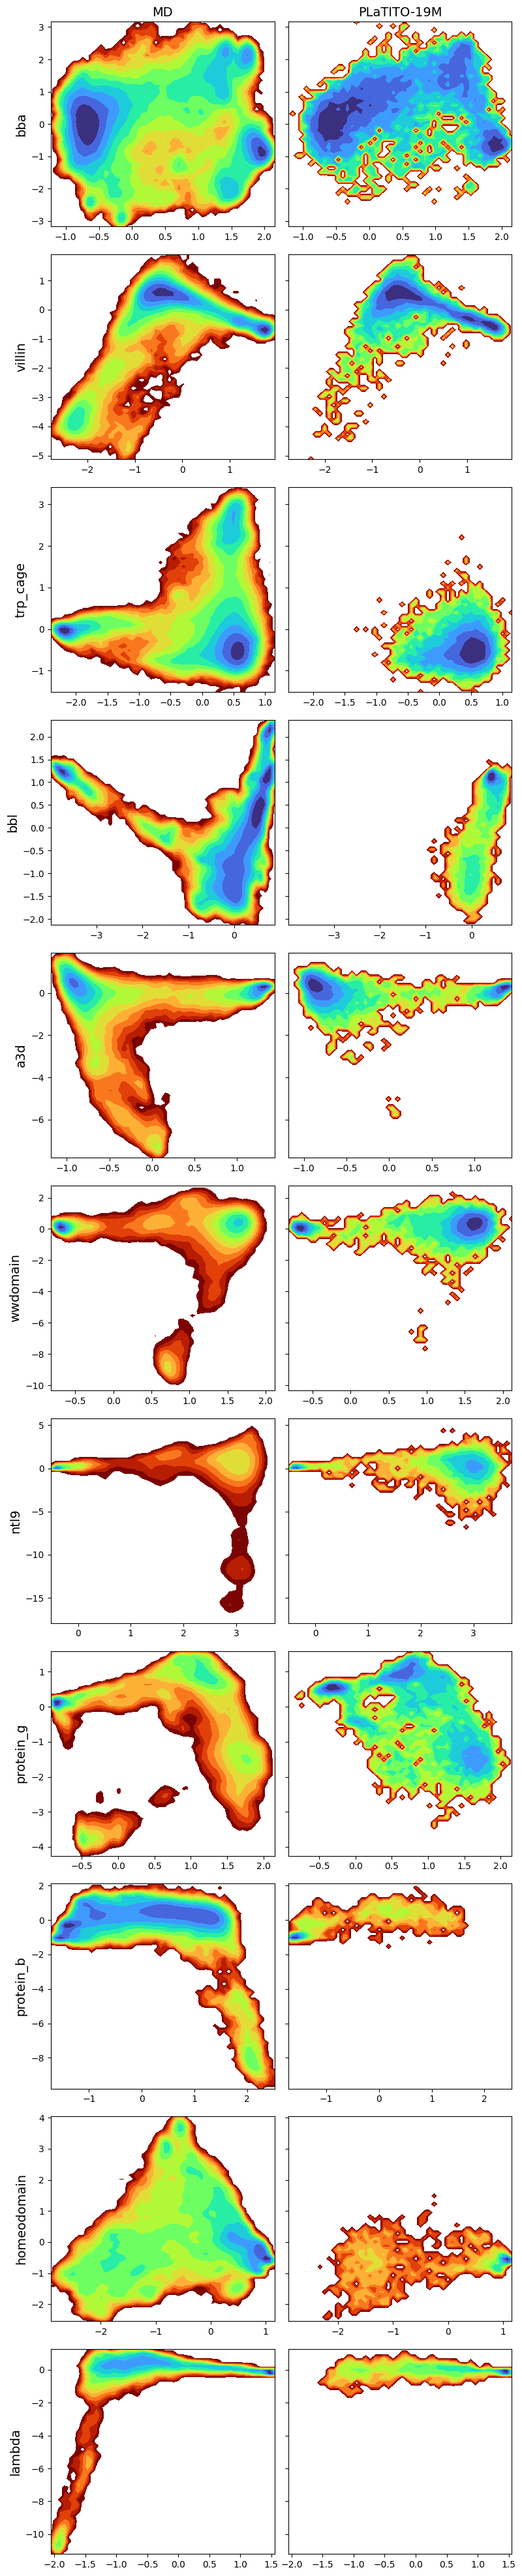

In [28]:
fig, axs = plt.subplots(n_proteins, 2, figsize=(8, 3.6 * n_proteins))

axs[0, 0].set_title("MD", fontsize=14)
axs[0, 1].set_title("PLaTITO-19M", fontsize=14)

for n, protein in enumerate(protein_names):
    x_range = (xedges[protein][0], xedges[protein][-1])
    y_range = (yedges[protein][0], yedges[protein][-1])

    ax = axs[n]
    ax[0].sharex(ax[1])
    ax[0].sharey(ax[1])
    ax[1].tick_params(labelleft=False)

    ax[0].set_ylabel(protein, fontsize=14)

    plot_free_energy_on_axes(
        ax[0], md_tica_features[protein],
        add_colorbar=False, kBT=kBT, max_energy=max_energy,
        levels=levels, num_bins=num_bins, x_range=x_range, y_range=y_range,
    )
    plot_free_energy_on_axes(
        ax[1], platito_tica_features[protein],
        add_colorbar=False, kBT=kBT, max_energy=max_energy,
        levels=levels, num_bins=num_bins, x_range=x_range, y_range=y_range,
    )

fig.tight_layout()
plt.show()

In [29]:
random_seed = 12345
n_resample = 1000000
sigma_resample = 0.25
num_bins = 50
energy_cutoff = 10.0
padding = 0.5

In [30]:
results_mae = {}
results_rmse = {}
results_coverage = {}

for protein in protein_names:
    results_mae[protein] = {}
    results_rmse[protein] = {}
    results_coverage[protein] = {}
    
    md_projection = md_tica_features[protein]
    temperature_K = temperatures[protein]
    metric = DistributionMetrics2D(
            md_projection,
            random_seed=random_seed,
            temperature_K=temperature_K,
            n_resample=n_resample,
            sigma_resample=sigma_resample,
            num_bins=num_bins,
            energy_cutoff=energy_cutoff,
            padding=padding,
        )
    
    mae_platito, rmse_platito, coverage_platito = metric.score_nonzero(platito_tica_features[protein])

    results_mae[protein]['PLaTITO-19M'] = mae_platito
    results_rmse[protein]['PLaTITO-19M'] = rmse_platito
    results_coverage[protein]['PLaTITO-19M'] = coverage_platito

In [31]:
def mean_and_std_over_proteins(results_dict):
    df = pd.DataFrame(results_dict).T  # rows: proteins, cols: methods
    return df.mean(axis=0), df.std(axis=0)

In [32]:
mae_mean, mae_std = mean_and_std_over_proteins(results_mae)
rmse_mean, rmse_std = mean_and_std_over_proteins(results_rmse)
cov_mean, cov_std = mean_and_std_over_proteins(results_coverage)

In [33]:
summary_df = pd.DataFrame({
    ("MAE", "mean"): mae_mean,
    ("MAE", "std"): mae_std,
    ("RMSE", "mean"): rmse_mean,
    ("RMSE", "std"): rmse_std,
    ("Coverage", "mean"): cov_mean,
    ("Coverage", "std"): cov_std,
})

summary_df.index.name = "Method"
summary_df = summary_df.round(3)
summary_df

MAE         RMSE        Coverage       
              mean   std   mean    std     mean    std
Method                                                
PLaTITO-19M  0.824  0.17  1.099  0.212    0.666  0.136